In [26]:
import ase.io
import ase
import pickle
import numpy as np
import matplotlib.pyplot as plt
from metropolis import MetropolisCalculator
from trial_moves import nudge_orientation
from potentials import quadrupole_potential, gay_berne_walsh

In [2]:
frames = ase.io.read("xyz_files/two_benzenes.xyz", ":")
ell_frames = ase.io.read("xyz_files/two_ells_with_axes.xyz", ":")
print("frames length: ", len(frames))
print("ell_frames length: ", len(ell_frames))
for ell_frame, frame in zip(ell_frames, frames):
    ell_frame.info["energy"] = frame.get_total_energy()

frames length:  4168
ell_frames length:  4168


In [20]:
def run_simulation(length, simulation_id=None, init_frame_idx=0):
    metro = MetropolisCalculator(ell_frames[init_frame_idx], energy_func="Walsh", pos_delt = 0, or_delt=0.01)
    metro.calculate_trajectory(length)
    return metro

metro = run_simulation(2000, init_frame_idx=5)

100  /  2000
200  /  2000
300  /  2000
400  /  2000
500  /  2000
600  /  2000
700  /  2000
800  /  2000
900  /  2000
1000  /  2000
1100  /  2000
1200  /  2000
1300  /  2000
1400  /  2000
1500  /  2000
1600  /  2000
1700  /  2000
1800  /  2000
1900  /  2000
2000  /  2000


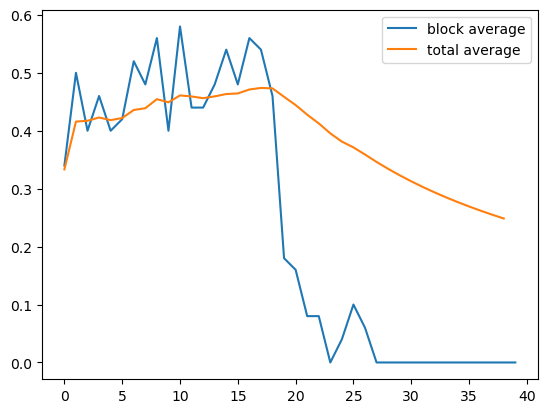

In [21]:
# plot average move acceptance rate
block_avgs = []
total_avgs = []
final_n = -1
n = 1
decisions = [dec.value for dec in metro.decisions]
while n < len(decisions[1:]) / 50:
    start = (n-1)*50 + 1
    stop = n*50 + 1
    avg = np.mean(decisions[start:stop])
    block_avgs.append(avg)
    total_avgs.append(metro.get_acc_rate(at_step=(50*n)+1))
    final_n = n
    n += 1
block_avgs.append(np.mean(decisions[final_n*50 + 1:]))
block_avgs = np.array(block_avgs)
plt.plot(block_avgs, label="block average")
plt.plot(total_avgs, label="total average")
plt.legend()
plt.show()

In [22]:
# record simulation trajectory as XYZ file
ase.io.write(f"simulations/testing/traj.xyz", metro.frames)

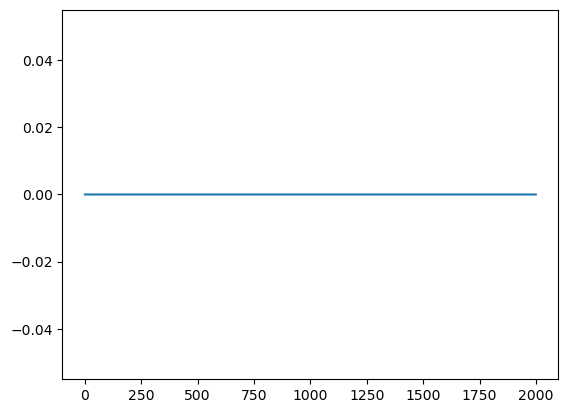

In [23]:
# Check that orientation is being updated
old_frame = metro.frames[0]
orientation_changes = []
for frame in metro.frames[1:]:
    old_ors = old_frame.arrays["or_vec"]
    new_ors = frame.arrays["or_vec"]
    orientation_changes.append(np.linalg.norm(new_ors - old_ors))

plt.plot(orientation_changes)

In [25]:
orientation_updates = [ell_frames[5]]
length = 100
i = 0
while i < length:
    nframe = nudge_orientation(orientation_updates[i], 0, 0.1)
    orientation_updates.append(nframe)
    i += 1

ase.io.write("simulations/testing/orientation_updates.xyz", orientation_updates)

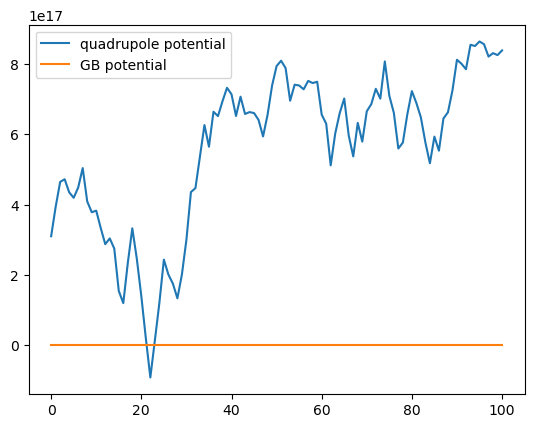

In [28]:
quadrupole_energies = [quadrupole_potential(frame) for frame in orientation_updates]
gb_energies = [gay_berne_walsh(frame) for frame in orientation_updates]
plt.plot(quadrupole_energies, label="quadrupole potential")
plt.plot(gb_energies, label="GB potential")
plt.legend()
plt.show()